# 01 Understanding Sequential Data and Time Series Prediction

## 📚 Learning Objectives

By completing this notebook, you will:
- **Understand** what sequential data is (order matters: time series, text, speech) and why we need models that use context (RNNs, Transformers)
- **Build** a **time series** dataset from a **real** log — daily 911 emergency-call volume for Montgomery County, Pennsylvania — and run a **baseline** that flattens the sequence (no RNN yet)
- **Measure** performance the honest way: against the cheap rules a domain expert would write in one line, not against a coin flip

## 🌍 Real life

**Where is this used?** Sequential data appears in **time series** (call volume, sensors, prices), **text** (sentences, documents), and **speech**. Order matters: "dog bites man" vs "man bites dog." Here we use a real emergency-dispatch log: 663,522 calls over 1,692 consecutive days. It has a genuine weekly rhythm (Friday is the busiest weekday, Sunday the quietest), real storm spikes, and a real COVID-19 collapse in spring 2020 — structure an invented sine wave would not have.

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 06 "RNN, LSTM, and GRU for Sequential Data" — you met sequence models there; here we start further back, from why order matters at all.

---

**📌 Covers slide(s):** **21** — Understanding Sequential Data. *Do this notebook after that slide.*

**Next:** `02_rnn_basics.ipynb` introduces RNNs for actual sequences.

---


## Theory (short)

- **Sequential data:** Order matters (e.g. time steps, words in a sentence). Examples: time series (call volume, sensors, prices), text, speech.
- **Time series prediction:** We use **past values** in the sequence to predict the **next value** (or a label). Here we slide a window of length `seq_len` over the series and predict the next day.
- **Why not a plain MLP?** A feedforward network can take flattened sequences but treats each position as an independent column; it does not model "what came before." In **02_rnn_basics** we use **RNNs** that maintain a hidden state over time.
- **Never shuffle a time series.** Splitting at random would train on the future and test on the past. Every split in this notebook is chronological.
- **A forecast has no meaning on its own.** It is only good *relative to* the cheapest rule that would also have worked: yesterday's value, the same weekday last week, or the training mean. We report all of them.


## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, pandas, scikit-learn, PyTorch. **Real data, already on disk** (no download): `Course 04/datasets/raw/montgomery_911_calls.csv` — 663,522 emergency calls logged by Montgomery County, PA between December 2015 and July 2020.

**Dataset:** We aggregate the raw call log into **one number per calendar day** (how many 911 calls arrived), giving 1,692 consecutive daily observations. A sliding window turns that series into (past 14 days → next day) pairs.

**Outputs:** Mean absolute error and RMSE for the next-day forecast, **side by side with three naive baselines**; then a direction-of-change classifier (LSTM) scored against a coin flip, the base rate, and a one-line weekday rule — with a significance test on the difference.

---


Real series: 1692 consecutive days, 2015-12-11 to 2020-07-28
Calls per day: mean 392, min 136, max 2187 (busiest day: 2018-03-02)
Mean calls by weekday: {'Mon': 400, 'Tue': 404, 'Wed': 411, 'Thu': 409, 'Fri': 425, 'Sat': 370, 'Sun': 326}

Train: 1342 days (up to 2019-08-27)   Test: 336 days (2019-08-28 to 2020-07-28)

Next-day forecast on the held-out period (lower is better):
model                                       MAE     RMSE
Ridge on 14 lags                          52.13    87.26
Naive: yesterday's count                  54.50   102.65
Naive: same weekday last week             57.80   113.12
Naive: training mean                      67.95   101.28


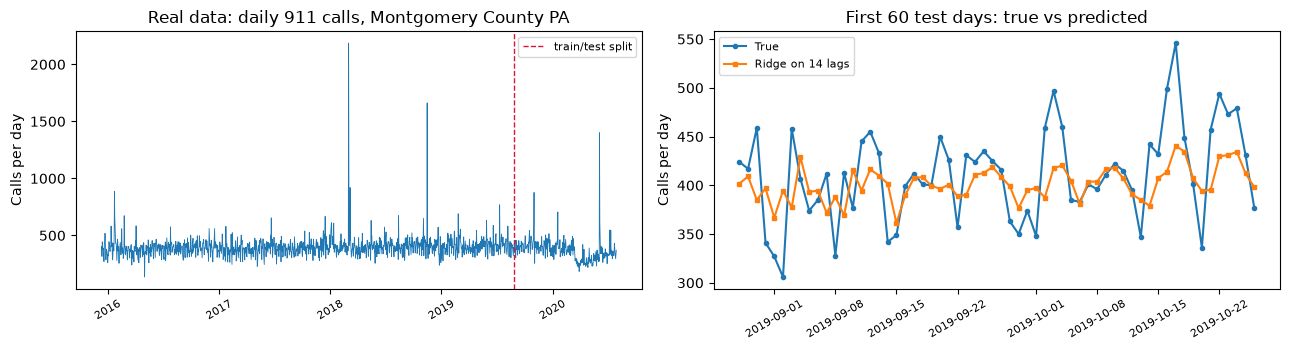

In [1]:
# WHAT: load a REAL time series - daily 911 emergency-call volume for Montgomery County, PA -
#       and predict tomorrow's call count from the past 14 days.
# WHY: sequential data only teaches you something when the order carries REAL structure.
#      This series has a genuine weekly rhythm, real storm spikes and a real COVID-19 drop;
#      an invented sine wave would have none of that.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# 1) Load the real call log and count how many calls arrived on each calendar day.
#    We only need the timestamp column, so we skip the other 8 columns (the file is 123 MB).
stamps = pd.to_datetime(
    pd.read_csv(data_path("montgomery_911_calls.csv"), usecols=["timeStamp"])["timeStamp"]
)
daily = stamps.dt.floor("D").value_counts().sort_index()
# The first and last calendar days are partial (logging starts mid-afternoon and stops
# mid-afternoon), so we drop them - otherwise two fake "quiet days" enter the series.
daily = daily.iloc[1:-1]

series = daily.to_numpy().astype(float)
dates = daily.index
print(f"Real series: {len(series)} consecutive days, {dates.min().date()} to {dates.max().date()}")
print(f"Calls per day: mean {series.mean():.0f}, min {series.min():.0f}, max {series.max():.0f} "
      f"(busiest day: {dates[series.argmax()].date()})")

# The weekly rhythm is real, not assumed - let the data state it.
by_dow = daily.groupby(daily.index.dayofweek).mean()
names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("Mean calls by weekday:", {names[k]: round(v) for k, v in by_dow.items()})

# 2) Build sequences: the past `seq_len` days are the input, the next day is the target.
seq_len = 14  # two full weeks, so the model can see the weekly cycle twice
X = np.stack([series[i:i + seq_len] for i in range(len(series) - seq_len)])
y = series[seq_len:]
y_dates = dates[seq_len:]

# 3) Chronological split - NEVER shuffle a time series: training on the future and
#    testing on the past leaks information and inflates every score.
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"\nTrain: {len(X_train)} days (up to {y_dates[split - 1].date()})   "
      f"Test: {len(X_test)} days ({y_dates[split].date()} to {y_dates[-1].date()})")

# 4) Baseline model: flatten the 14-day window and fit a linear model.
#    It ignores order structure entirely - each lag is just another column.
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 5) Honest comparison. A forecast is only good RELATIVE to the cheap rules it must beat.
naive_yesterday = X_test[:, -1]        # "tomorrow looks like today"
naive_lastweek = X_test[:, -7]         # "tomorrow looks like the same weekday last week"
naive_mean = np.full_like(y_test, y_train.mean())  # "always predict the training average"

print("\nNext-day forecast on the held-out period (lower is better):")
print(f"{'model':38s} {'MAE':>8s} {'RMSE':>8s}")
for name, pred in [
    ("Ridge on 14 lags", y_pred),
    ("Naive: yesterday's count", naive_yesterday),
    ("Naive: same weekday last week", naive_lastweek),
    ("Naive: training mean", naive_mean),
]:
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    print(f"{name:38s} {mae:8.2f} {rmse:8.2f}")

# 6) Plot the real series and the forecast on a slice of the test period.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(dates, series, lw=0.6)
axes[0].axvline(y_dates[split], color="crimson", ls="--", lw=1, label="train/test split")
axes[0].set_title("Real data: daily 911 calls, Montgomery County PA")
axes[0].set_ylabel("Calls per day")
axes[0].legend(fontsize=8)
axes[1].plot(y_dates[split:split + 60], y_test[:60], label="True", marker="o", ms=3)
axes[1].plot(y_dates[split:split + 60], y_pred[:60], label="Ridge on 14 lags", marker="s", ms=3)
axes[1].set_title("First 60 test days: true vs predicted")
axes[1].set_ylabel("Calls per day")
axes[1].legend(fontsize=8)
for ax in axes:
    ax.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout()
plt.show()


## 🌍 Real-World Worked Example — Predicting Whether Tomorrow Is Busier (and an Honesty Check)

**Industry context:** Dispatch centres, ride-hailing platforms and hospital admissions teams all
run sequence models over call/demand volume to plan staffing. The headline number in those
projects is almost always quoted against a **coin flip** — and that comparison is the wrong one.

We train an **LSTM** to predict whether tomorrow will bring **more** 911 calls than today, from
the last 21 days of real call volume. Unlike an invented random walk, this series does contain a
real signal: the county's **weekly rhythm**. So the model *will* beat 50%. The question the rest
of the cell answers is the one that matters — does it beat the **one-line rule** that captures
that same weekly rhythm?

*Preview: this example uses an **LSTM**, which notebooks `02`–`03` introduce properly. Run it as a demo now and revisit the model code after `03_lstm_advanced`.*


Train 1336 days, test 335 days (2019-08-29 to 2020-07-28)



P(calls rise tomorrow) by weekday, measured on the training years:
   Mon 0.93  Tue 0.57  Wed 0.51  Thu 0.44  Fri 0.59  Sat 0.16  Sun 0.21

LSTM on 21 days of history:         66.9%
Coin flip (the number demos quote):  50.0%
Base rate (always guess majority):  53.1%  (test period is 46.9% 'up' days)
One-line weekday rule:              62.4%

LSTM edge over a coin flip:      +16.9 points  <- the flattering number
LSTM edge over the weekday rule:  +4.5 points  <- the honest number

McNemar: LSTM right & rule wrong on 79 days; rule right & LSTM wrong on 64 days.
Exact two-sided p = 0.24

HONEST READING: the weekly signal is REAL - you can see it in the table above, and both
predictors exploit it. But the LSTM's remaining edge over the one-line rule is NOT
statistically distinguishable from zero (p = 0.24). On this data, three weeks of
history plus 12,994 LSTM parameters buy no reliable improvement over 'what weekday is it?'.
Report it that way. The lesson is not that LSTMs are useless - 

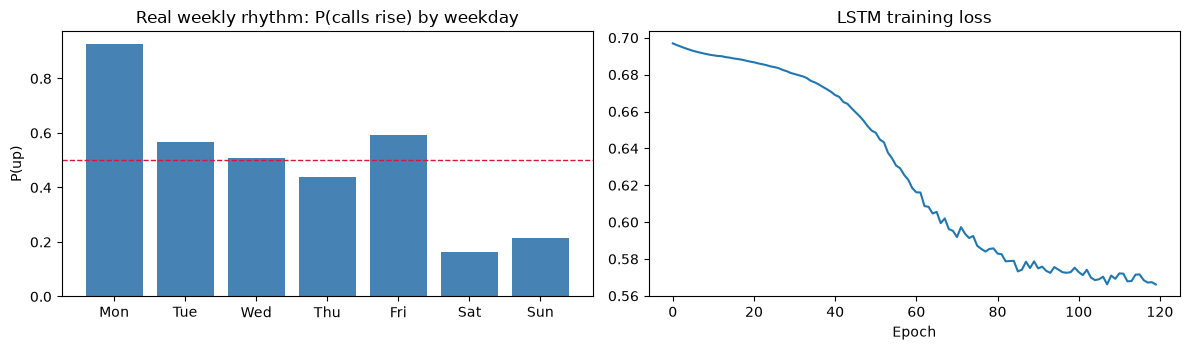

In [2]:
# WHAT: train an LSTM to predict the DIRECTION of tomorrow's 911 call volume (up or down),
#       then score it against the baselines an honest report would have to include.
# WHY: the gap above a coin flip is the flattering number. The gap above a rule a dispatcher
#      could write from memory is the honest one - and here they are very different.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import binomtest

torch.manual_seed(0)

# ── Real data: the same daily 911 call counts loaded above ──────────────────
SEQ_LEN = 21  # three weeks of history
seq_x = np.stack([series[i:i + SEQ_LEN] for i in range(len(series) - SEQ_LEN)]).astype(np.float32)
target = series[SEQ_LEN:]
# Label 1 = tomorrow has MORE calls than today, 0 = the same or fewer.
labels = (target > seq_x[:, -1]).astype(np.int64)
label_dates = dates[SEQ_LEN:]

# Normalise each window on its own mean/std so the model learns the SHAPE of the last
# three weeks rather than the absolute traffic level of that stretch of history.
seq_n = (seq_x - seq_x.mean(1, keepdims=True)) / (seq_x.std(1, keepdims=True) + 1e-8)

cut = int(0.8 * len(seq_n))  # chronological split again
Xtr = torch.tensor(seq_n[:cut]).unsqueeze(-1)          # (N, 21, 1)
Ytr = torch.tensor(labels[:cut])
Xte = torch.tensor(seq_n[cut:]).unsqueeze(-1)
Yte = torch.tensor(labels[cut:])
print(f"Train {len(Xtr)} days, test {len(Xte)} days "
      f"({label_dates[cut].date()} to {label_dates[-1].date()})")

# ── LSTM ────────────────────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # classify from the last time step

model = TrendLSTM()
opt = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses = []
for epoch in range(120):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    lstm_pred = model(Xte).argmax(1).numpy()
y_true = labels[cut:]
acc = (lstm_pred == y_true).mean()

# ── Baseline 1: always predict the majority class (the base rate) ───────────
p_up = y_true.mean()
base = max(p_up, 1.0 - p_up)

# ── Baseline 2: a one-line rule a dispatcher could write from memory ────────
# For each weekday, does call volume usually rise? Fit that on TRAIN only, apply to TEST.
dow = np.array([d.dayofweek for d in label_dates])
up_rate_by_dow = np.array([labels[:cut][dow[:cut] == k].mean() for k in range(7)])
rule_pred = (up_rate_by_dow[dow[cut:]] > 0.5).astype(np.int64)
rule_acc = (rule_pred == y_true).mean()

names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print("\nP(calls rise tomorrow) by weekday, measured on the training years:")
print("   " + "  ".join(f"{names[k]} {up_rate_by_dow[k]:.2f}" for k in range(7)))

print(f"\nLSTM on 21 days of history:         {acc * 100:.1f}%")
print(f"Coin flip (the number demos quote):  50.0%")
print(f"Base rate (always guess majority):  {base * 100:.1f}%  (test period is {p_up * 100:.1f}% 'up' days)")
print(f"One-line weekday rule:              {rule_acc * 100:.1f}%")
print(f"\nLSTM edge over a coin flip:      {(acc - 0.5) * 100:+.1f} points  <- the flattering number")
print(f"LSTM edge over the weekday rule:  {(acc - rule_acc) * 100:+.1f} points  <- the honest number")

# ── Is that remaining edge real? McNemar's test on the SAME test days ───────
# Count the days where exactly one of the two predictors was right.
lstm_only = int(((lstm_pred == y_true) & (rule_pred != y_true)).sum())
rule_only = int(((lstm_pred != y_true) & (rule_pred == y_true)).sum())
p_value = binomtest(lstm_only, lstm_only + rule_only, 0.5).pvalue
print(f"\nMcNemar: LSTM right & rule wrong on {lstm_only} days; rule right & LSTM wrong on {rule_only} days.")
print(f"Exact two-sided p = {p_value:.2f}")
print("\nHONEST READING: the weekly signal is REAL - you can see it in the table above, and both")
print("predictors exploit it. But the LSTM's remaining edge over the one-line rule is NOT")
n_params = sum(p.numel() for p in model.parameters())
print(f"statistically distinguishable from zero (p = {p_value:.2f}). On this data, three weeks of")
print(f"history plus {n_params:,} LSTM parameters buy no reliable improvement over 'what weekday is it?'.")
print("Report it that way. The lesson is not that LSTMs are useless - it is that the baseline you")
print("choose decides whether your result reads as a breakthrough or as a rounding error.")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].bar(names, up_rate_by_dow, color="steelblue")
axes[0].axhline(0.5, color="crimson", ls="--", lw=1)
axes[0].set_title("Real weekly rhythm: P(calls rise) by weekday")
axes[0].set_ylabel("P(up)")
axes[1].plot(losses)
axes[1].set_title("LSTM training loss")
axes[1].set_xlabel("Epoch")
plt.tight_layout(); plt.show()


## Summary

**What you did:** (1) Turned a **real** emergency-call log into a daily time series (1,692 consecutive days). (2) Built sliding-window sequences (past 14 days → next day). (3) Trained a Ridge baseline on the flattened window and scored it against three naive rules. (4) Trained an LSTM to predict the direction of change and scored it against a coin flip, the base rate, and a one-line weekday rule.

**What actually happened — read the numbers, not the hype:**
- The Ridge model on 14 lags reached **MAE ≈ 52 calls/day**, versus **54.5** for "yesterday's count" and **57.8** for "same weekday last week." A real improvement, but a small one — about **4%** better than doing nothing clever.
- The LSTM direction classifier reached **66.9%**, which looks like **+16.9 points over a coin flip**. Against the one-line weekday rule (**62.4%**) the edge shrinks to **+4.5 points**, and McNemar's test on the same 335 test days gives **p ≈ 0.24** — i.e. not distinguishable from zero.
- The held-out period runs from August 2019 to July 2020, so it contains the **COVID-19 collapse** (call volume fell about 30% between mid-March and end of May 2020). Part of every model's test error here is a genuine distribution shift, not model weakness. Real series do this; sine waves do not.

**In real life you'd also:** Add calendar features (holiday, month), model the COVID break explicitly, and evaluate with rolling-origin cross-validation rather than one split.

**The main idea:** Order carries real structure — and *most of the exploitable structure in a real series is usually cheap to capture*. Always publish the naive baselines next to the model.

**Next:** `02_rnn_basics.ipynb` introduces RNNs for sequences.


## 📚 References

1. Elman, J. L. (1990). *Finding Structure in Time*. Cognitive Science 14(2), 179-211. https://doi.org/10.1207/s15516709cog1402_1
2. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation 9(8), 1735-1780. https://doi.org/10.1162/neco.1997.9.8.1735
3. Lim, B. & Zohren, S. (2021). *Time-Series Forecasting With Deep Learning: A Survey*. Philosophical Transactions of the Royal Society A. https://arxiv.org/abs/2004.13408
4. Makridakis, S., Spiliotis, E. & Assimakopoulos, V. (2018). *Statistical and Machine Learning Forecasting Methods: Concerns and Ways Forward*. PLoS ONE 13(3): e0194889. https://doi.org/10.1371/journal.pone.0194889 — the large-scale study showing ML forecasters routinely losing to simple statistical baselines, which is exactly what the naive-baseline table above is guarding against.
5. Hyndman, R. J. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.), Ch. 5.2 "Some simple forecasting methods". https://otexts.com/fpp3/simple-methods.html — definitions of the naive and seasonal-naive benchmarks used here.

**Data source:** Montgomery County, Pennsylvania 911 emergency-call log, 2015-2020 (`Course 04/datasets/raw/montgomery_911_calls.csv`), 663,522 calls. Published as an open dataset; used here unmodified apart from aggregating to daily counts.
